# Julia Drop Simulations


## Notebook overview

This notebook simulates a droplet impacting a spherical substrate using a Newton-based solve for the modal shape and pressure.

Typical run order:
1) Install/import packages (if needed).
2) Set user inputs and derived constants.
3) Run the main simulation loop.
4) Generate plots/animations.
5) Run diagnostics if results look unstable.


## Prior Package Installations

It is necessary to have the Julia kernel installed before using this notebook. Instructions can be found here: https://julialang.github.io/IJulia.jl/stable/manual/installation/.


Other package installations may be required. The main known ones are listed below. They can be added through this notebook, or the Julia CLI. You may expect a few minutes for this to be completed. Once the packages are installed once in a session, there is no need to install them again, as opposed to fecthing imports.


In [1]:
"""import Pkg; Pkg.add("Animations")
import Pkg; Pkg.add("Colors")
import Pkg; Pkg.add("ColorSchemes")
import Pkg; Pkg.add("GLMakie")"""

"import Pkg; Pkg.add(\"Animations\")\nimport Pkg; Pkg.add(\"Colors\")\nimport Pkg; Pkg.add(\"ColorSchemes\")\nimport Pkg; Pkg.add(\"GLMakie\")"

## Main imports

In [2]:
using LinearAlgebra
using SpecialFunctions
using FastGaussQuadrature
using DelimitedFiles
using ProgressMeter
using Printf
using LegendrePolynomials
using ColorSchemes

# For 3D plotting and animation
using Plots
using GeometryBasics: Point3f0, TriangleFace, Mesh
using GLMakie
using CairoMakie
using Statistics
using Animations
using Colors
plotlyjs()

WebIO._IJuliaInit()

Plots.PlotlyJSBackend()

## User input


In [3]:
#Physical ants
rho_in_CGS = 1 #Gr/cm^3
sigma_in_CGS = 72 #Dyne/cm
g_in_CGS = 980 #Cm/s2
nu_in_GCS = 0.05 #cm2/s

#Geometry
R_in_CGS = 0.2 #Cm
R_s = 1.0 # Spherical substrate radius
Ra = R_s / R_in_CGS  # Dimensionless substrate radius ratio

#Initial speed in meters per second
V_in_CGS = 2 #Cm/s

#Total simulation time
T_end = 5 #In dimensionless units

#Numerical parameters
n_thetas = 40
n_sampling_time_L_mode = 16 #Not any less than 8

16

### Constants derived directly from user input


In [4]:
# Initial height
H_in_CGS = max(R_in_CGS, R_s) # centimeter-gram-second

# Units
unit_length_in_CGS = R_in_CGS
unit_time_in_CGS = sqrt(rho_in_CGS * R_in_CGS^3 / sigma_in_CGS)
unit_mass_in_CGS = rho_in_CGS * R_in_CGS^3

# Dimensionless constants
We = rho_in_CGS * V_in_CGS^2 * R_in_CGS / sigma_in_CGS
Bo = rho_in_CGS * g_in_CGS * R_in_CGS^2 / sigma_in_CGS
Oh = nu_in_GCS * sqrt(rho_in_CGS / (sigma_in_CGS * R_in_CGS))

# Numerical constants
delta_time_max = (2 * pi) / (sqrt(n_thetas * (n_thetas + 2) * (n_thetas - 1)) * n_sampling_time_L_mode)
n_times_base = ceil(Int, T_end / delta_time_max)

# Initialize list of times
times_list = collect(0:delta_time_max:(n_times_base*delta_time_max))

# Dimensionless initial conditions
V = -sqrt(We)
H = H_in_CGS / unit_length_in_CGS

cos_min = 1e-6

# Rebuild angular grid consistently (cos_theta_vec, theta_vec)
roots, weights = gausslegendre(n_thetas)  # keep weights if used elsewhere
# Map Gauss-Legendre nodes from (-1, 1) to (0, 1) and clamp away from 0
cos_nodes = clamp.((roots .+ 1) ./ 2, cos_min, 1.0)
# Include north pole explicitly; total length = n_thetas + 1
cos_theta_vec = vcat(1.0, reverse(cos_nodes))
theta_vec = acos.(cos_theta_vec)
# With this construction, all cos_theta are positive and the maximum admissible q is the full range
q_last = n_thetas + 1

# another possible grid construction
# roots, weights = gausslegendre(n_thetas)
# cos_theta_vec = vcat(1, reverse(roots))
# theta_vec = acos.(cos_theta_vec)
# q_last = findfirst(x -> x <= 0, cos_theta_vec) - 1

41

## Helper Functions


In [5]:
# Newton's Method Tolerance variables
const NEWTON_TOL_F = 1e-8
const NEWTON_TOL_X = 1e-10
const NEWTON_MAXIT = 100
const NEWTON_MAX_BACKTRACK = 60
const EPS_ACCEPT = 1e-6
const MAX_DT_HALVINGS = 12
const MAX_M_JUMP = 2

2

In [6]:
function Legendre(x::Float64, n::Int)
    """
    Function that evaluates nth Legendre polynomial at x using the LegendrePolynomials package.

    Inputs:
    - x (Float64): X-value at which Legendre polynomial is evaluated
    - n (Int): Number of Legendre polynomial to be evaluated

    Output:
    - value (Float64): Value of nth Legendre polynomial at x
    """
    if n == n_thetas && x != 1
        # To avoid numerical errors very close to zero
        value = 0.0
    else
        value = LegendrePolynomials.Pl(x, n)
    end
    return value
end

Legendre (generic function with 1 method)

In [7]:
# Helpers to organize the vector input to the Non-Linear System
"""
Pack the state vector for the Newton solve.
A, U, B are modal amplitudes, velocities, and pressures; h, v are center-of-mass height/velocity.
"""
function pack_x(A, U, B, h, v)
    return vcat(A, U, B, h, v)
end

"""
Unpack a state vector into modal amplitudes, velocities, pressures, and center-of-mass values.
"""
function unpack_x(x)
    nA = n_thetas - 1
    nU = n_thetas - 1
    nB = n_thetas + 1
    
    A = @view x[1:nA]
    U = @view x[(nA + 1):(nA + nU)]
    B = @view x[(nA + nU + 1):(nA + nU + nB)]
    h = x[end - 1]
    v = x[end]
    return A, U, B, h, v
end


unpack_x

In [8]:
"""
Evaluate the radial deformation eta at a collocation point.
"""
function eta_at(cos_theta, A)
    s = 0.0
    @inbounds for j in 1:length(A)
        l = j + 1
        s += A[j] * Legendre(cos_theta, l)
    end
    return s
end

eta_at

In [9]:
# Row of F with the spherical contact condition
"""
Compute the contact constraint residual at a collocation point.
"""
function contact_F_row(cos_theta, theta, A, h, Ra)
    eta = eta_at(cos_theta, A)
    sin_theta = sin(theta)
    radicand = 1 - (1 + eta / Ra)^2 * sin_theta^2
    radicand < 0 && return NaN # constact condition is not satisfied
    return eta - (h + Ra * (1 - sqrt(radicand))) / cos_theta + 1
end

contact_F_row

In [10]:
# Row with the linear pressure condition
"""
Evaluate the pressure expansion at a collocation point.
"""
function pressure_at(cos_theta, B)
    pressure_sum = 0.0 # Initialize the sum
    @inbounds for l in 0:n_thetas
        pressure_sum += B[l + 1] * Legendre(cos_theta, l)
    end
    return pressure_sum
end

pressure_at

In [11]:
# Check if the geometry is valid
# sqrt radicands ≥ 0
# no penetration outside contact (only enforce outside the contact set)
# q is within bounds

const DEBUG_GEOM = false

const GEOM_RAD_TOL = -1e-10
const GEOM_PEN_TOL = -1e-5

# Upper-hemisphere-only points: cos_theta in [cos_min, 1]
# We avoid cos_theta too close to 0 to prevent numerical singular behavior near the equator.
"""
Check basic geometric validity: nonnegative radicands, optional no-penetration outside contact, and q bounds.
"""
function geometry_valid(A, h, q, Ra; enforce_penetration::Bool=true)
    for ind_theta in 1:(n_thetas + 1)
        cos_theta = cos_theta_vec[ind_theta]
        theta = theta_vec[ind_theta]
        sin_theta = sin(theta)

        eta = eta_at(cos_theta, A)
        radicand = 1 - (1 + eta / Ra)^2 * sin_theta^2

        if radicand < GEOM_RAD_TOL
            DEBUG_GEOM && println("geom fail: radicand<0 at ind=$ind_theta cos_theta=$cos_theta rad=$radicand")
            return false
        end

        radicand = max(radicand, 0.0)
        sphere_height = Ra * (1 - sqrt(radicand))
        droplet_height = h + (1 + eta) * cos_theta

        # Only enforce no-penetration OUTSIDE the contact region.
        # Contact indices are 1:q (consistent with F_system contact loop).
        if enforce_penetration && ind_theta > q && (droplet_height - sphere_height) < GEOM_PEN_TOL
            DEBUG_GEOM && println("geom fail: penetration outside contact at ind=$ind_theta cos_theta=$cos_theta gap=$(droplet_height - sphere_height)")
            return false
        end
    end

    q < 0 && return false
    q > q_last && return false
    return true
end

geometry_valid

In [12]:
"""
Construct the E matrix used to couple pressure modes in the system.
"""
function E_mat()
    L = n_thetas
    E = zeros(L - 1, L + 1)
    @inbounds for i in 1:(L - 1)
        l = i + 1
        E[i, l + 1] = l
    end
    return E
end

E_mat

In [13]:
# Obtain the K vector used in the system at F(x)
"""
Return the K vector used in the center-of-mass equation.
"""
function K_vec()
    K = zeros(n_thetas + 1)
    K[2] = -1.0
    return K
end

K_vec

In [14]:
# Obtain the system of non-linear equations
"""
Nonlinear residual F(x, q) for one time step of the Newton solve.
"""
function F_system(x, q, params)
    A_prev, U_prev, h_prev, v_prev, delta_t, Bo, Oh, Ra = params
    A, U, B, h, v = unpack_x(x) # unpack inside the function to simplif the parameters

    L = n_thetas # number of spherical harmonics
    F = zeros(3 * L + 1) # system of non-linear equations

    @inbounds for i in 1:(L - 1) # time integration of A
        F[i] = A[i] - delta_t * U[i] - A_prev[i] 
    end

    @inbounds for i in 1:(L - 1) # time integration of U
        l = i + 1
        C = (l - 1) * l * (l + 2)
        D = 1 + delta_t * 2 * (2 * l + 1) * (l - 1) * Oh
        F[(L - 1) + i] = delta_t * C * A[i] + D * U[i] + delta_t * l * B[l + 1] - U_prev[i]
    end

    if q > 0 
        @inbounds for i in 1:q
            cos_theta = cos_theta_vec[i]
            theta = theta_vec[i]
            F[2 * (L - 1) + i] = contact_F_row(cos_theta, theta, A, h, Ra) # contact conditions
        end
    end

    @inbounds for i in (q + 1):(L + 1)
        F[2 * (L - 1) + q + (i - q)] = pressure_at(cos_theta_vec[i], B) # pressure conditions
    end
    
    # center of mass equations
    F[end - 1] = h - delta_t * v - h_prev

    K = K_vec()
    # v - v_prev + delta_t*Bo + delta_t*(K·B) = 0, with K[2] = -1 => term is -delta_t*B1
    F[end] = v - v_prev + delta_t * Bo + delta_t * dot(K, B)

    return F
end

F_system

In [15]:
# Filling the Jacobian used in the non-linear system of equations
"""
Jacobian of F_system for the Newton solve.
"""
function J_system(x, q, params)
    A_prev, U_prev, h_prev, v_prev, delta_t, Bo, Oh, Ra = params
    A, U, B, h, v = unpack_x(x)

    L = n_thetas
    n = 3 * L + 1
    J = zeros(n, n)

    nA = L - 1
    nU = L - 1
    nB = L + 1
    iA = 1
    iU = iA + nA
    iB = iU + nU
    ih = iB + nB
    iv = ih + 1

    # Block row 1: [I, -delta_t I, 0 , 0 , 0]
    @inbounds for i in 1:(L - 1)
        J[i, iA - 1 + i] = 1.0
        J[i, iU - 1 + i] = -delta_t
    end

    # Block row 2: [delta_t C, D, delta_t E, 0, 0]
    E = E_mat()
    @inbounds for i in 1:(L - 1)
        l = i + 1
        C = (l - 1) * l * (l + 2)
        D = 1 + delta_t * 2 * (2 * l + 1) * (l - 1) * Oh
        row = (L - 1) + i
        J[row, iA - 1 + i] = delta_t * C
        J[row, iU - 1 + i] = D
        for j in 1:(L + 1)
            J[row, iB - 1 + j] = delta_t * E[i, j]
        end
    end

    # Block row 3: contact condition derivatives
    if q > 0
        @inbounds for i in 1:q
            cos_theta = cos_theta_vec[i]
            theta = theta_vec[i]
            sin_theta = sin(theta)

            eta = eta_at(cos_theta, A)
            radicand = 1 - (1 + eta / Ra)^2 * sin_theta^2
            radicand = max(radicand, 0.0)
            denom = sqrt(radicand)

            # For F_contact = eta - (h + Ra(1 - sqrt(radicand)))/cos + 1
            # d/deta[Ra(1 - sqrt(radicand))] = (1 + eta/Ra)*sin^2 / sqrt(radicand)
            # => dF/deta = 1 - (1/cos) * (1 + eta/Ra)*sin^2 / sqrt(radicand)
            dFdeta = denom == 0.0 ? NaN : (1 - ((1 + eta / Ra) * sin_theta^2) / (cos_theta * denom))

            row = 2 * (L - 1) + i
            for j in 1:(L - 1)
                l = j + 1
                Pl = Legendre(cos_theta, l)
                J[row, iA - 1 + j] = dFdeta * Pl
            end
            J[row, ih] = -1 / cos_theta
        end
    end

    # Block row 4: H^q block (pressure constraints)
    @inbounds for i in (q + 1):(L + 1)
        row = 2 * (L - 1) + q + (i - q)
        cos_theta = cos_theta_vec[i]
        for l in 0:L
            J[row, iB - 1 + (l + 1)] = Legendre(cos_theta, l)
        end
    end

    # Block row 5: [0, 0, 0, 1, - delta_t]
    J[end - 1, ih] = 1.0
    J[end - 1, iv] = -delta_t

    # Block row 6: [0, 0, delta_t K, 0, 1]
    K = K_vec()
    J[end, iv] = 1.0
    @inbounds for j in 1:(L + 1)
        J[end, iB - 1 + j] = delta_t * K[j]
    end

    return J
end

J_system

## Newton's Method Solver

In [16]:
const NEWTON_LOG_FULL = false  # set true only if you really want full x/F vectors

struct NewtonLogConfig
    enabled::Bool
    print_live::Bool
    keep_history::Bool
end

const NEWTON_LOG_DEFAULT = NewtonLogConfig(false, false, true)

summarize_vec(v) = (
    norm2 = norm(v),
    normInf = norm(v, Inf),
    min = minimum(v),
    max = maximum(v),
)

function newton_solve(x0, q, params; logcfg::NewtonLogConfig=NEWTON_LOG_DEFAULT, logstore=nothing, context=nothing)
    x = copy(x0)

    emit(event) = begin
        if logcfg.enabled
            if logcfg.keep_history && logstore !== nothing
                push!(logstore, event)
            end
            if logcfg.print_live
                println(event)
            end
        end
    end

    for it in 1:NEWTON_MAXIT
        Fx = F_system(x, q, params)
        Fx_finite = all(isfinite, Fx)
        Fx_sum = Fx_finite ? summarize_vec(Fx) : nothing

        emit((; type=:iter_start, context=context, q=q, it=it, Fx_finite=Fx_finite, Fx=Fx_sum))

        if !Fx_finite
            emit((; type=:fail_nonfinite_F, context=context, q=q, it=it))
            return x, false
        end

        if norm(Fx) <= NEWTON_TOL_F
            emit((; type=:converged, context=context, q=q, it=it, Fx=Fx_sum))
            return x, true
        end

        Jx = J_system(x, q, params)
        J_finite = all(isfinite, Jx) && !any(isnan.(Jx))
        emit((; type=:jacobian, context=context, q=q, it=it, J_finite=J_finite))

        if !J_finite
            emit((; type=:fail_nonfinite_J, context=context, q=q, it=it))
            return x, false
        end

        delta_x = try
            Jx \ (-Fx)
        catch err
            emit((; type=:fail_linsolve, context=context, q=q, it=it, err=string(err)))
            return x, false
        end

        dx_finite = all(isfinite, delta_x)
        dx_sum = dx_finite ? summarize_vec(delta_x) : nothing
        emit((; type=:step_dir, context=context, q=q, it=it, delta_x_finite=dx_finite, delta_x=dx_sum))

        if !dx_finite
            emit((; type=:fail_nonfinite_delta, context=context, q=q, it=it))
            return x, false
        end

        # Backtracking
        Fx_norm = norm(Fx)
        alpha = 1.0

        best_trial = Inf
        best_alpha = 0.0
        best_x = nothing

        accepted = false

        for bt in 1:NEWTON_MAX_BACKTRACK
            x_trial = x .+ alpha .* delta_x
            A_trial, U_trial, B_trial, h_trial, v_trial = unpack_x(x_trial)

            # During line search, only enforce radicand validity. Allow temporary penetration
            # so Newton can converge and the outer loop/epsilon can enforce impenetrability.
            geom_ok = geometry_valid(A_trial, h_trial, q, params[end]; enforce_penetration=false)
            emit((; type=:bt_geom, context=context, q=q, it=it, bt=bt, alpha=alpha, geom_ok=geom_ok))

            if !geom_ok
                alpha *= 0.5
                continue
            end

            F_trial = F_system(x_trial, q, params)
            F_trial_finite = all(isfinite, F_trial)
            trial_norm = F_trial_finite ? norm(F_trial) : Inf

            emit((;
                type=:bt_residual,
                context=context,
                q=q,
                it=it,
                bt=bt,
                alpha=alpha,
                F_trial_finite=F_trial_finite,
                F_trial=(F_trial_finite ? summarize_vec(F_trial) : nothing),
                trial_norm=trial_norm,
                improved=(trial_norm < Fx_norm),
            ))

            if !F_trial_finite
                alpha *= 0.5
                continue
            end

            if trial_norm < best_trial
                best_trial = trial_norm
                best_alpha = alpha
                best_x = copy(x_trial)
            end

            if trial_norm < Fx_norm
                x .= x_trial
                accepted = true
                emit((; type=:bt_accept, context=context, q=q, it=it, bt=bt, alpha=alpha, trial_norm=trial_norm))
                break
            end

            alpha *= 0.5
        end

        if !accepted
            emit((; type=:bt_fail, context=context, q=q, it=it, Fx_norm=Fx_norm, best_trial=best_trial, best_alpha=best_alpha))

            if best_x !== nothing && best_trial < Fx_norm
                x .= best_x
                emit((; type=:bt_accept_best, context=context, q=q, it=it, alpha=best_alpha, best_trial=best_trial))
            else
                emit((; type=:fail_no_accepted_step, context=context, q=q, it=it, Fx_norm=Fx_norm, best_trial=best_trial))
                return x, false
            end
        end

        if NEWTON_LOG_FULL && logcfg.enabled
            emit((; type=:x_full, context=context, q=q, it=it, x=copy(x)))
        end
    end

    emit((; type=:fail_maxit, context=context, q=q, it=NEWTON_MAXIT))
    return x, false
end

newton_solve (generic function with 1 method)

In [17]:
"""
Feasibility metric for a given contact index q; returns Inf when constraints fail.
"""
function epsilon_for_q(x, q, params)
    A, U, B, h, v = unpack_x(x)
    Ra = params[end]

    # epsilon1_q: impenetrability outside contact (strict > 0)
    # Outside contact is i = q+1 ... q_last
    if q < q_last
        for i in (q + 1):q_last
            cos_theta = cos_theta_vec[i]
            theta_ = theta_vec[i]
            sintheta_ = sin(theta_)
            eta = eta_at(cos_theta, A)
            radicand = 1 - (1 + eta / Ra)^2 * sintheta_^2
            radicand < -1e-12 && return Inf
            radicand = max(radicand, 0.0)
            sphere_height = Ra * (1 - sqrt(radicand))
            droplet_height = h + (1 + eta) * cos_theta
            gap = droplet_height - sphere_height
            if !(isfinite(gap) && gap >= -1e-12)
                return Inf
            end
        end
    end

    # If everything is in contact, there's no "boundary" point q+1 to compare to
    # Return 0 (best) rather than Inf so q=q_last isn't forbidden
    if q >= q_last
        return 0.0
    end

    # epsilon2_q: tangential residual near the contact boundary
    q1 = max(q, 1)
    q2 = q1 + 1
    if q2 > q_last
        return 0.0
    end

    cos_theta1 = cos_theta_vec[q1]
    theta_1 = theta_vec[q1]
    R1 = contact_F_row(cos_theta1, theta_1, A, h, Ra)

    cos_theta2 = cos_theta_vec[q2]
    theta_2 = theta_vec[q2]
    R2 = contact_F_row(cos_theta2, theta_2, A, h, Ra)

    if !(isfinite(R1) && isfinite(R2))
        return Inf
    end

    epsilon2 = abs(R1 * cos_theta1 - R2 * cos_theta2)
    return epsilon2
end

epsilon_for_q

In [18]:
const DEBUG_EVALQ = true

function evaluate_q(x0, q, params)
    x, converged = newton_solve(x0, q, params)
    if !converged
        DEBUG_EVALQ && println("  evaluate_q: Newton failed for q=$q")
        return Inf, nothing
    end
    epsilon = epsilon_for_q(x, q, params)
    return epsilon, x
end

evaluate_q (generic function with 1 method)

In [19]:
const DEBUG_Q = true 

function select_q(x_prev, q_prev, params)
    function scan(qmin, qmax)
        best_q = q_prev
        best_epsilon = Inf
        best_x = nothing

        for q in qmin:qmax
            epsilon, x = evaluate_q(x_prev, q, params)
            DEBUG_Q && println("  scan q=$q -> epsilon=$epsilon x_is_nothing=$(x===nothing)")
            if epsilon < best_epsilon
                best_q = q
                best_epsilon = epsilon
                best_x = x
            end
        end
        return best_q, best_x, best_epsilon
    end

    qmin1 = max(0, q_prev - 2)
    qmax1 = min(q_last, q_prev + 2)
    DEBUG_Q && println("select_q: window1 [$qmin1, $qmax1]")
    best_q, best_x, best_epsilon = scan(qmin1, qmax1)

    if best_x === nothing || !isfinite(best_epsilon)
        qmin2 = max(0, q_prev - 8)
        qmax2 = min(q_last, q_prev + 8)
        DEBUG_Q && println("select_q: window2 [$qmin2, $qmax2]")
        best_q, best_x, best_epsilon = scan(qmin2, qmax2)
    end

    if best_x === nothing || !isfinite(best_epsilon)
        DEBUG_Q && println("select_q: full sweep [0, $q_last]")
        best_q, best_x, best_epsilon = scan(0, q_last)
    end

    return best_q, best_x, best_epsilon
end

select_q (generic function with 1 method)

In [20]:
function north_and_south_pole(all_amps_vec, h)
    """
    Function that evaluates the deformed droplet's north and south pole radii.

    Inputs:
    all_amps_vec (Vector): Vector of amplitudes at a single point in time.
    h (Float64): Height of the center of mass.

    Outputs:
    deformed_north_pole_radius (Float64): Radius at the north pole.
    deformed_south_pole_radius (Float64): Radius at the south pole.
    """

    undeformed_north_pole_radius = 1.0
    undeformed_south_pole_radius = 1.0

    # Adding deformations from the Legendre modes
    # Corrected range to include n_thetas
    for i in 2:n_thetas
        undeformed_north_pole_radius += all_amps_vec[i-1] * Legendre(1.0, i)
        undeformed_south_pole_radius += all_amps_vec[i-1] * Legendre(-1.0, i)
    end

    # North pole: _theta = 0, sin(pi/2) = 1; South pole: _theta = pi, sin(3pi/2) = -1
    deformed_north_pole_radius = undeformed_north_pole_radius 
    deformed_south_pole_radius = undeformed_south_pole_radius

    return deformed_north_pole_radius, deformed_south_pole_radius
end

north_and_south_pole (generic function with 1 method)

In [21]:
function maximum_radius(all_amps_vec)
    """
    Function that calculates the maximum radius of the droplet at a single point in time.

    Inputs:
    all_amps_vec (Vector): Vector of amplitudes at a single point in time.

    Outputs:
    radius_of_largest_deformation (Float64): Maximum radius achieved at any sampled angle.
    """

    radii = ones(n_thetas + 1) # Set radii at all sampled points to undeformed radius
    # Corrected loop range to include all modes up to n_thetas
    for i in 2:n_thetas
        for ind_angles in 1:(n_thetas+1) # Adding deformation
            radii[ind_angles] += all_amps_vec[i-1] * Legendre(cos_theta_vec[ind_angles], i)
        end
    end

    radius_of_largest_deformation = maximum(radii)
    return radius_of_largest_deformation # Returning largest radius
end

maximum_radius (generic function with 1 method)

In [22]:
"""
Compute the minimum radius of the droplet at a single time step.
"""
function minimum_radius(all_amps_vec)
    radii = ones(n_thetas + 1)
    for i in 2:n_thetas
        for ind_angles in 1:(n_thetas+1)
            radii[ind_angles] += all_amps_vec[i-1] * Legendre(cos_theta_vec[ind_angles], i)
        end
    end
    return minimum(radii)
end

minimum_radius

In [23]:
# compute the coefficient of restitution
"""
Estimate the coefficient of restitution from time-series data around first lift-off.
"""
function coefficient_of_restitution(all_h_list, all_v_list, all_m_list, all_time_list)
    index = nothing
    for i in 2:length(all_m_list)-1
        if all_m_list[i] == 0 && all_m_list[i-1] > 0
            index = i
            break
        end
    end
    index === nothing && return nothing

    final_velocity = (all_v_list[index] + all_v_list[index-1]) / 2
    final_height = (all_h_list[index] + all_h_list[index-1]) / 2
    contact_height = all_h_list[index-1]
    contact_time = (all_time_list[index] + all_time_list[index-1]) / 2

    delta_h = final_height - contact_height
    coeff_rest_squared = ((Bo * delta_h) + 0.5 * (final_velocity^2)) / (0.5 * We)
    coeff_rest_squared_float = sqrt(abs(float(coeff_rest_squared)))

    return coeff_rest_squared_float, contact_time
end

coefficient_of_restitution

In [24]:
# compute the maximum contact radius
"""
Compute the maximum contact radius over the simulation.
"""
function maximum_contact_radius(all_amps_list, all_m_list)
    max_radius = 0.0
    for (amps, m) in zip(all_amps_list, all_m_list)
        if m == 0
            continue
        end
        upper = min(m + 1, length(theta_vec))
        for idx in 1:upper
            cos_theta = cos_theta_vec[idx]
            sin_theta = sin(theta_vec[idx])
            # Fixed off-by-one error: l+2 -> l+1 to match mode indexing (amps[1] is mode 2)
            eta = sum(amps[l] * Legendre(cos_theta, l + 1) for l in eachindex(amps))
            radial = abs((1 + eta) * sin_theta)
            max_radius = max(max_radius, radial)
        end
    end
    return max_radius
end

maximum_contact_radius

In [25]:
"""
Return the minimum gap and radicand margins over collocation points.
"""
function geometry_margins(A, h, Ra)
    min_gap = Inf
    min_rad = Inf
    min_gap_i = 0
    min_rad_i = 0

    for i in 1:q_last
        cos_theta = cos_theta_vec[i]
        theta_ = theta_vec[i]
        sintheta_ = sin(theta_)

        eta = eta_at(cos_theta, A)
        radicand = 1 - (1 + eta / Ra)^2 * sintheta_^2
        if radicand < min_rad
            min_rad = radicand
            min_rad_i = i
        end

        rad = max(radicand, 0.0)
        sphere_h = Ra * (1 - sqrt(rad))
        drop_h = h + (1 + eta) * cos_theta
        gap = drop_h - sphere_h
        if gap < min_gap
            min_gap = gap
            min_gap_i = i
        end
    end

    return min_gap, min_gap_i, min_rad, min_rad_i
end

geometry_margins

In [26]:
"""
Compute the minimum contact index q required to avoid penetration for a given geometry.
"""
function required_q_from_geometry(A, h, Ra; tol=1e-12)
    q_req = 0
    for i in 1:q_last
        cos_theta = cos_theta_vec[i]
        theta_ = theta_vec[i]
        sintheta_ = sin(theta_)
        eta = eta_at(cos_theta, A)
        radicand = 1 - (1 + eta / Ra)^2 * sintheta_^2
        if radicand < -1e-12
            return nothing  # geometry invalid regardless of q
        end
        radicand = max(radicand, 0.0)
        sphere_height = Ra * (1 - sqrt(radicand))
        droplet_height = h + (1 + eta) * cos_theta
        gap = droplet_height - sphere_height
        if gap < -tol
            q_req = i  # needs to be inside contact up through i
        end
    end
    return q_req
end

required_q_from_geometry

## Main Simulation Loop


In [27]:
"""
Main simulation loop:

This version uses:
- Inner nonlinear solve (Newton) for fixed q: F_system(x,q)=0
- Outer discrete search: choose q minimizing epsilon(q)
- Adaptive timestep: reject/halve delta_t when invalid or contact changes too quickly

Outputs/ Creates/ Appends:
all_amps_list (Vector): List of all amplitudes at all time steps.
all_amps_vel_list (Vector): List of all velocities of amplitudes at all time steps.
all_press_list (Vector): List of all pressure amplitudes at all time steps.
all_h_list (Vector): List of heights of the center of mass of the droplet at every time step.
all_v_list (Vector): List of velocities of the center of mass of the droplet at every time step.
all_m_list (Vector): List of contact points at every time step.
all_north_poles_list (Vector): List of north poles at every time step.
all_south_poles_list (Vector): List of south poles at every time step.
all_maximum_radii_list (Vector): List of maximum radii at every time step.
all_times_list (Vector): List of all time steps.
"""

struct SimLogConfig
    enabled::Bool
    print_every::Int       # print accepted-step summary every N accepted steps
    print_guess::Bool      # print guess geometry margins each attempt
    print_rejects::Bool    # print reject reasons
end

const SIM_LOG_DEFAULT = SimLogConfig(true, 100, true, true)

function log_step(cfg::SimLogConfig, msg)
    cfg.enabled && println(msg)
end

function log_reject(cfg::SimLogConfig, msg)
    cfg.enabled && println(msg)
end

# Always re-initialize the simulation state for a fresh run
amps_prev_vec = zeros(n_thetas - 1)
amps_vel_prev_vec = zeros(n_thetas - 1)
press_prev_vec = zeros(n_thetas + 1)
h_prev = H
v_prev = V
m_prev = 0

# Initialize lists
all_amps_list = [copy(amps_prev_vec)]
all_amps_vel_list = [copy(amps_vel_prev_vec)]
all_press_list = [copy(press_prev_vec)]
all_h_list = [h_prev]
all_v_list = [v_prev]
all_m_list = [m_prev]
all_north_poles_list = [north_and_south_pole(amps_prev_vec, h_prev)[1]]
all_south_poles_list = [north_and_south_pole(amps_prev_vec, h_prev)[2]]
all_maximum_radii_list = [maximum_radius(amps_prev_vec)]
all_minimum_radii_list = [minimum_radius(amps_prev_vec)]

all_times_list = [0.0]

# Initial guess for Newton at k+1
x_prev = pack_x(amps_prev_vec, amps_vel_prev_vec, press_prev_vec, h_prev, v_prev)

# Time stepping parameters
# For stiff regimes (large Bo/We/Ra), starting at delta_time_max can cause endless rejects
delta_t = delta_time_max / 16
min_delta_t = 1e-14
max_total_steps = 20000

# Outer-loop geometry tolerances (should be consistent with geometry_valid tolerances)
GAP_TOL = GEOM_PEN_TOL
RAD_TOL = GEOM_RAD_TOL

# State
t = 0.0
step = 0
println("Starting Newton-based simulation loop...")
p = ProgressUnknown(desc="Simulating", dt=0.5)

simlog = SIM_LOG_DEFAULT
accepted_steps = 0
rejected_steps = 0

while t < T_end && step < max_total_steps
    step += 1
    params = (amps_prev_vec, amps_vel_prev_vec, h_prev, v_prev, delta_t, Bo, Oh, Ra)

    A_guess = amps_prev_vec .+ delta_t .* amps_vel_prev_vec
    U_guess = copy(amps_vel_prev_vec)
    B_guess = copy(press_prev_vec)
    h_guess = h_prev + delta_t * v_prev
    v_guess = v_prev
    x_guess = pack_x(A_guess, U_guess, B_guess, h_guess, v_guess)

    if simlog.print_guess
        A_g, U_g, B_g, h_g, v_g = unpack_x(x_guess)
        mgap, igap, mrad, irad = geometry_margins(A_g, h_g, Ra)
        log_step(simlog, "TRY step=$step t=$t dt=$delta_t m_prev=$m_prev | guess min_gap=$(mgap)@i=$(igap) min_radicand=$(mrad)@i=$(irad)")
    end

    q_new, x_new, epsilon = select_q(x_guess, m_prev, params)
    log_step(simlog, "SELECT step=$step t=$t dt=$delta_t | q_new=$q_new epsilon=$epsilon x_new_is_nothing=$(x_new===nothing)")

    reject = false
    reject_reason = ""

    if x_new === nothing
        reject = true
        reject_reason = "newton_failed_all_q"
    else
        Atrial, Utrial, Btrial, htrial, vtrial = unpack_x(x_new)

        delta_A = norm(Atrial .- amps_prev_vec) / max(norm(amps_prev_vec), 1.0)
        A_JUMP_TOL = 0.5
        if delta_A > A_JUMP_TOL
            reject = true
            reject_reason = "A_jump"
        end

        geom_ok = geometry_valid(Atrial, htrial, q_new, Ra)

        mgap_trial, igap_trial, mrad_trial, irad_trial = geometry_margins(Atrial, htrial, Ra)

        if mrad_trial < RAD_TOL
            reject = true
            reject_reason = "radicand_margin"
        elseif mgap_trial < GAP_TOL
            reject = true
            reject_reason = "gap_margin"
        end

        if !isfinite(epsilon)
            reject = true
            reject_reason = "epsilon_nonfinite"
        elseif abs(q_new - m_prev) > MAX_M_JUMP
            reject = true
            reject_reason = "q_jump"
        elseif !geom_ok
            reject = true
            reject_reason = "geometry_invalid"
        end
    end

    if reject
        rejected_steps += 1
        simlog.print_rejects && log_step(simlog, "REJECT step=$step t=$t dt=$delta_t | reason=$reject_reason m_prev=$m_prev q_new=$q_new epsilon=$epsilon")
        if delta_t <= min_delta_t
            log_step(simlog, "STOP min_dt step=$step t=$t dt=$delta_t | reason=$reject_reason m_prev=$m_prev q_new=$q_new epsilon=$epsilon")
            break
        else
            delta_t *= 0.5
            continue
        end
    end

    # Accept
    t += delta_t
    accepted_steps += 1
    m_prev = q_new
    x_prev = x_new

    A, U, B, h, v = unpack_x(x_new)
    amps_prev_vec = copy(A)
    amps_vel_prev_vec = copy(U)
    press_prev_vec = copy(B)
    h_prev = h
    v_prev = v

    push!(all_amps_list, copy(amps_prev_vec))
    push!(all_amps_vel_list, copy(amps_vel_prev_vec))
    push!(all_press_list, copy(press_prev_vec))
    push!(all_h_list, h_prev)
    push!(all_v_list, v_prev)
    push!(all_m_list, m_prev)
    push!(all_north_poles_list, north_and_south_pole(amps_prev_vec, h_prev)[1])
    push!(all_south_poles_list, north_and_south_pole(amps_prev_vec, h_prev)[2])
    push!(all_maximum_radii_list, maximum_radius(amps_prev_vec))
    push!(all_minimum_radii_list, minimum_radius(amps_prev_vec))

    push!(all_times_list, t)
    next!(p; showvalues=[(:t, t), (:dt, delta_t), (:m, m_prev), (:eps, epsilon), (:rej, rejected_steps)])

    if accepted_steps % simlog.print_every == 0
        log_step(simlog, "ACCEPT step=$step acc=$accepted_steps rej=$rejected_steps | t=$t dt=$delta_t m=$m_prev epsilon=$epsilon h=$h_prev v=$v_prev")
    end
end
finish!(p)
log_step(simlog, "DONE steps=$step accepted=$accepted_steps rejected=$rejected_steps final_t=$t")

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/kVZZH/src/ProgressMeter.jl:594
Simulating 89    Time: 0:04:00


DONE steps=124 accepted=89 rejected=35 final_t=0.008150267902123894


In [28]:
"""
OPTIONAL: Extra debugging steps
@show accepted_steps rejected_steps t delta_t
@show length(all_times_list) length(all_h_list) length(all_north_poles_list) length(all_south_poles_list) length(all_m_list)

@show all_times_list[1:min(end, 5)]
@show all_h_list[1:min(end, 5)]
@show all_m_list[1:min(end, 5)]

z_north = all_h_list .+ all_north_poles_list
z_south = all_h_list .- all_south_poles_list

@show any(!isfinite, all_times_list) any(!isfinite, all_h_list) any(!isfinite, z_north) any(!isfinite, z_south)

@show z_north[1:min(end, 5)]
@show z_south[1:min(end, 5)]
"""

"OPTIONAL: Extra debugging steps\n@show accepted_steps rejected_steps t delta_t\n@show length(all_times_list) length(all_h_list) length(all_north_poles_list) length(all_south_poles_list) length(all_m_list)\n\n@show all_times_list[1:min(end, 5)]\n@show all_h_list[1:min(end, 5)]" ⋯ 25 bytes ⋯ "nd, 5)]\n\nz_north = all_h_list .+ all_north_poles_list\nz_south = all_h_list .- all_south_poles_list\n\n@show any(!isfinite, all_times_list) any(!isfinite, all_h_list) any(!isfinite, z_north) any(!isfinite, z_south)\n\n@show z_north[1:min(end, 5)]\n@show z_south[1:min(end, 5)]\n"

# Plotting


### Heights


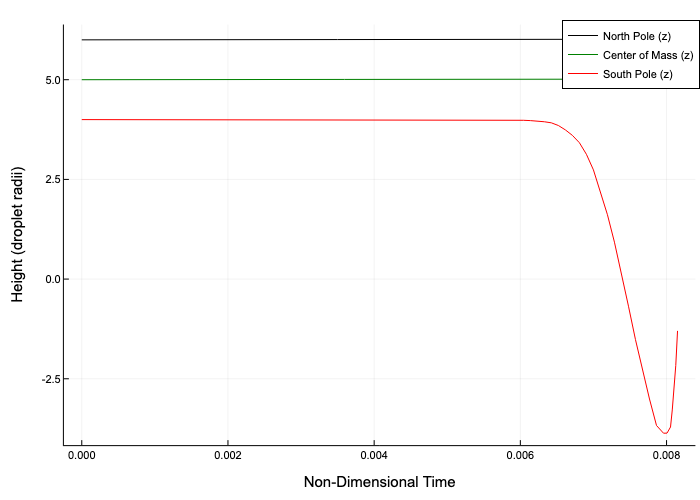

In [29]:
"""
Creating a plot of all north pole, south pole and center of mass heights and saves it to a designated folder.

Inputs/ Uses:
all_north_poles_list (list): List of north poles at every time step.
all_south_poles_list (list): List of south poles at every time step.
all_h_list (list): List of heights of the center of mass of the droplet at every time step.
all_times_list (list): List of all time steps.

Outputs:
plot_path (saved plot): Saves plot on computer.
    
"""

t = all_times_list

z_north = all_h_list .+ all_north_poles_list
z_south = all_h_list .- all_south_poles_list

plt = Plots.plot(t, z_north, label="North Pole (z)", color=:black, legend=:best)
Plots.plot!(plt, t, all_h_list, label="Center of Mass (z)", color=:green)
Plots.plot!(plt, t, z_south, label="South Pole (z)", color=:red)

Plots.xlabel!(plt, "Non-Dimensional Time")
Plots.ylabel!(plt, "Height (droplet radii)")

Plots.savefig(plt, "heights_plot.png")
display(plt)

### Maximum Radius


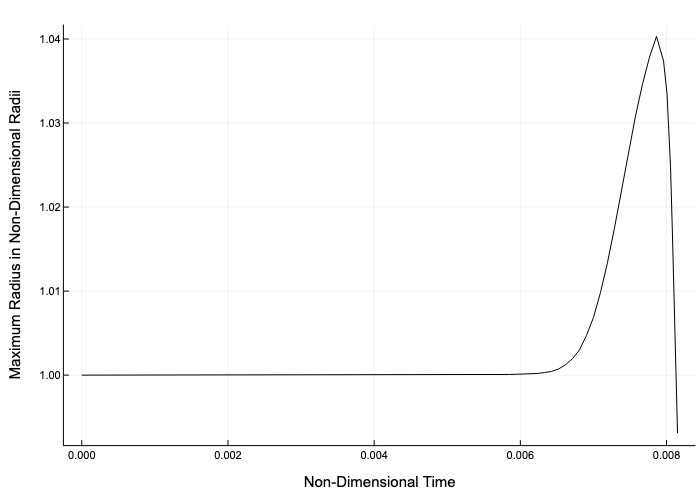

In [30]:
"""
Creates a plot of the maximum droplet radius over time and saves it to a designated path on your computer. 

Inputs/ Uses:
all_maximum_radii_list (list): List of maximum radii at every time step.
all_times_list (list): List of all time steps.

Outputs:
plot_path (saved plot): Saves plot on computer.
"""

# Use the time list recorded during simulation
t = all_times_list

# Plot and label using Plots.jl explicitly to avoid ambiguity
plt = Plots.plot(
    t, all_maximum_radii_list,
    color=:black,
    xlabel="Non-Dimensional Time",
    ylabel="Maximum Radius in Non-Dimensional Radii",
    legend=false
)
Plots.savefig(plt, "maximum_radius_plot.png")
display(plt)

### Development of Amplitudes


Amplitude development plot saved as development_of_amplitudes.png


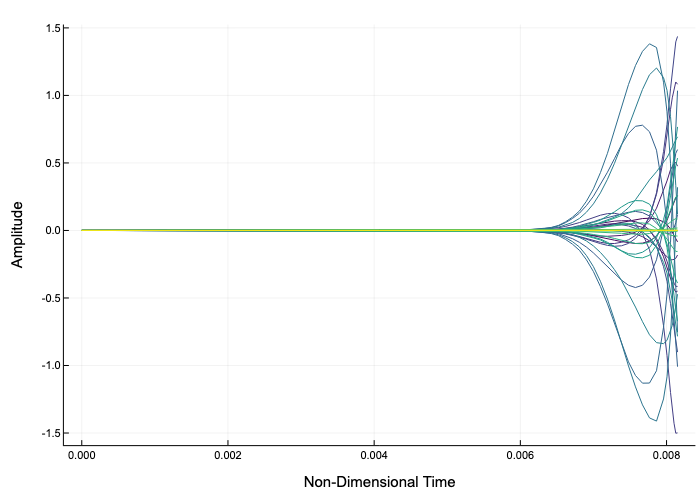

In [31]:
all_amps_arr = hcat(all_amps_list...)' # Convert to array for easier handling

function development_of_amplitudes(all_amps_arr, all_times_list, n_thetas)
    t = all_times_list

    # Choose colors from viridis colormap
    colors = get(ColorSchemes.viridis, LinRange(0, 1, n_thetas))

    plt = Plots.plot()  # Initialize empty plot

    for amp_ind in 1:(n_thetas-1)
        # Extract the column for the current amplitude index
        # Using simple indexing assuming all_amps_arr contains scalars
        coefficients_list = all_amps_arr[:, amp_ind]
        Plots.plot!(plt, t, coefficients_list, color=colors[amp_ind], label="")
    end

    Plots.xlabel!(plt, "Non-Dimensional Time")
    Plots.ylabel!(plt, "Amplitude")
    
    # Save the plot
    Plots.savefig(plt, "development_of_amplitudes.png")
    println("Amplitude development plot saved as development_of_amplitudes.png")
    
    display(plt)
end

# call the function with your data
development_of_amplitudes(all_amps_arr, all_times_list, n_thetas)

# Animations


## 3D Droplet Simulation


In [32]:
# draw the spherical substrate surface
function draw_spherical_substrate!(ax, Ra, layers=60)
    phi = range(0, 2*pi, length=layers)
    theta_sphere = range(0, pi / 2, length=30)  # upper hemisphere

    x_sphere = zeros(length(theta_sphere), layers)
    y_sphere = zeros(length(theta_sphere), layers)
    z_sphere = zeros(length(theta_sphere), layers)

    for (i, theta_) in enumerate(theta_sphere)
        for (j, phi) in enumerate(phi)
            x_sphere[i, j] = Ra * sin(theta_) * cos(phi)
            y_sphere[i, j] = Ra * sin(theta_) * sin(phi)
            # North pole at z=0, equator at z=-Ra
            z_sphere[i, j] = -Ra * (1 - cos(theta_))
        end
    end

    GLMakie.surface!(ax, x_sphere, y_sphere, z_sphere, colormap=:grays, alpha=0.7)
    
    # optional debug: mark the north pole (should be at origin)
    GLMakie.scatter!(ax, [0.0], [0.0], [0.0], color=:red, markersize=15)
end

draw_spherical_substrate! (generic function with 2 methods)

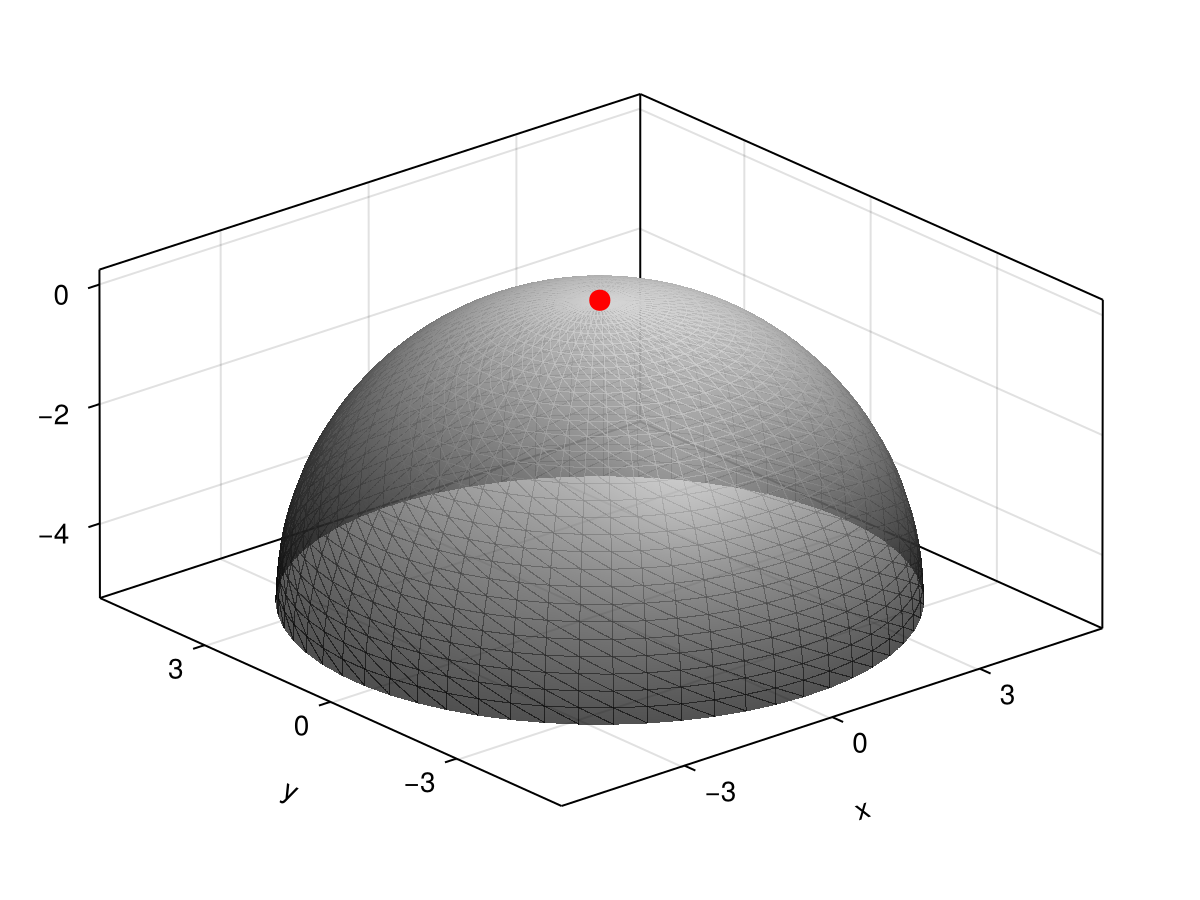

In [33]:
# Test
fig = GLMakie.Figure()
ax = GLMakie.Axis3(fig[1, 1]; aspect=:data)
draw_spherical_substrate!(ax, Ra)
fig

In [34]:
"""
Animate the 3D droplet surface over time using the mode amplitudes and center-of-mass height.
"""
function drop_simulation(all_amps_list, all_h_list, all_m_list, all_times_list,  n_thetas_int; speeds=20, view_vertical=20, view_horizontal=50,
    layers=60, r_min=1e-3,
    R0=1.0,
    eta_max=0.08,
    l_cut=8)

    # Angular grids
    theta_max = π # to have a circular droplet shape
    theta = range(0, theta_max, length=n_thetas_int)
    cos_theta = cos.(theta)
    sin_theta = sin.(theta)

    phi = range(0, 2π, length=layers)
    cos_phi = cos.(phi)
    sin_phi = sin.(phi)

    # Legendre modes
    all_amps_arr = hcat(all_amps_list...)'
    M = size(all_amps_arr, 2)

    legvals = zeros(n_thetas_int, M) # get a 2 dimensional array with size n_thetas_int x M 
    for l in 2:(M + 1)
        @inbounds for i in 1:n_thetas_int
            legvals[i, l - 1] = Legendre(cos_theta[i], l)
        end
    end

    l = collect(2:(M + 1)) # collecting the legendre modes 
    taper = exp.(-((l .- 2) ./ max(l_cut - 2, 1)).^4)  
    taper[l .<= l_cut] .= 1.0

    # Figure and Axis 
    fig = GLMakie.Figure(size=(600, 600))
    ax = GLMakie.Axis3(fig[1, 1]; aspect=:data)

    rxy = max(1.5, Ra + 1.0)
    z_center = -Ra / 2
    z_extent = max(Ra, R0) * 1.5

    limits!(ax,(-rxy, rxy),(-rxy, rxy),(z_center - z_extent, z_center + z_extent))

    cam3d!(ax.scene; elevation=view_vertical, azimuth=view_horizontal)
    draw_spherical_substrate!(ax, Ra, layers)

    # Buffers
    x_layer = zeros(n_thetas_int, layers)
    y_layer = similar(x_layer)
    z_layer = similar(x_layer)

    radii = similar(theta)
    eta = zeros(n_thetas_int)

    # Geometry
    function compute_surface!(x, y, z, r, h)
        @inbounds for i in 1:n_thetas_int
            ri = r[i]
            rhoi = ri * sin_theta[i]
            zi = h + ri * cos_theta[i]
            for j in 1:layers
                x[i, j] = rhoi * cos_phi[j]
                y[i, j] = rhoi * sin_phi[j]
                z[i, j] = zi
            end
        end
    end

    radii .= R0
    h_eff = -R0 * cos(theta_max)

    compute_surface!(x_layer, y_layer, z_layer, radii, h_eff)

    surfaceplot = GLMakie.surface!(ax, x_layer, y_layer, z_layer, colormap=:blues)
    contact = GLMakie.scatter!(ax, [0.0], [0.0], [0.0], color=:green, markersize=20)

    # Animation
    frame_indices = 1:2:length(all_amps_list)
    p = Progress(length(frame_indices); desc="Rendering droplet.gif", dt=0.5)

    GLMakie.record(fig, "droplet.gif", frame_indices; framerate=speeds) do frame
        @inbounds begin
            fill!(eta, 0.0)
            for col in 1:M
                eta .+= taper[col] * all_amps_arr[frame, col] .* view(legvals, :, col)
            end

            eta_infty = maximum(abs.(eta))
            scale = eta_infty > 0 ? min(1.0, eta_max / eta_infty) : 1.0

            radii .= R0 .* (1 .+ scale .* eta)
            radii .= max.(radii, r_min)

            # dynamic height (rebound)
            h_offset = all_h_list[1]  # or the frame where contact begins
            h_dyn = h_eff + (all_h_list[frame] - h_offset)

            # contact detection
            gap_min = Inf
            for i in 1:n_thetas_int
                rho = radii[i] * sin_theta[i]
                if rho < Ra
                    z_drop = h_dyn + radii[i] * cos_theta[i]
                    z_dome = -Ra * (1 - sqrt(1 - (rho / Ra)^2))
                    gap_min = min(gap_min, z_drop - z_dome)
                end
            end

            in_contact = gap_min ≤ 1e-3 * R0

            # non-penetration clamp
            if in_contact && h_dyn < h_eff
                h_dyn = h_eff
            end

            compute_surface!(x_layer, y_layer, z_layer, radii, h_dyn)

            surfaceplot[1] = x_layer
            surfaceplot[2] = y_layer
            surfaceplot[3] = z_layer

            contact.color[] = in_contact ? :red : :green
        end
        next!(p)
        surfaceplot, contact
    end

    finish!(p)
    return fig
end



drop_simulation

## Droplet 3D Simulation + Cross Section 

Progress: 100%|█████████████████████████████████████████| Time: 0:00:18


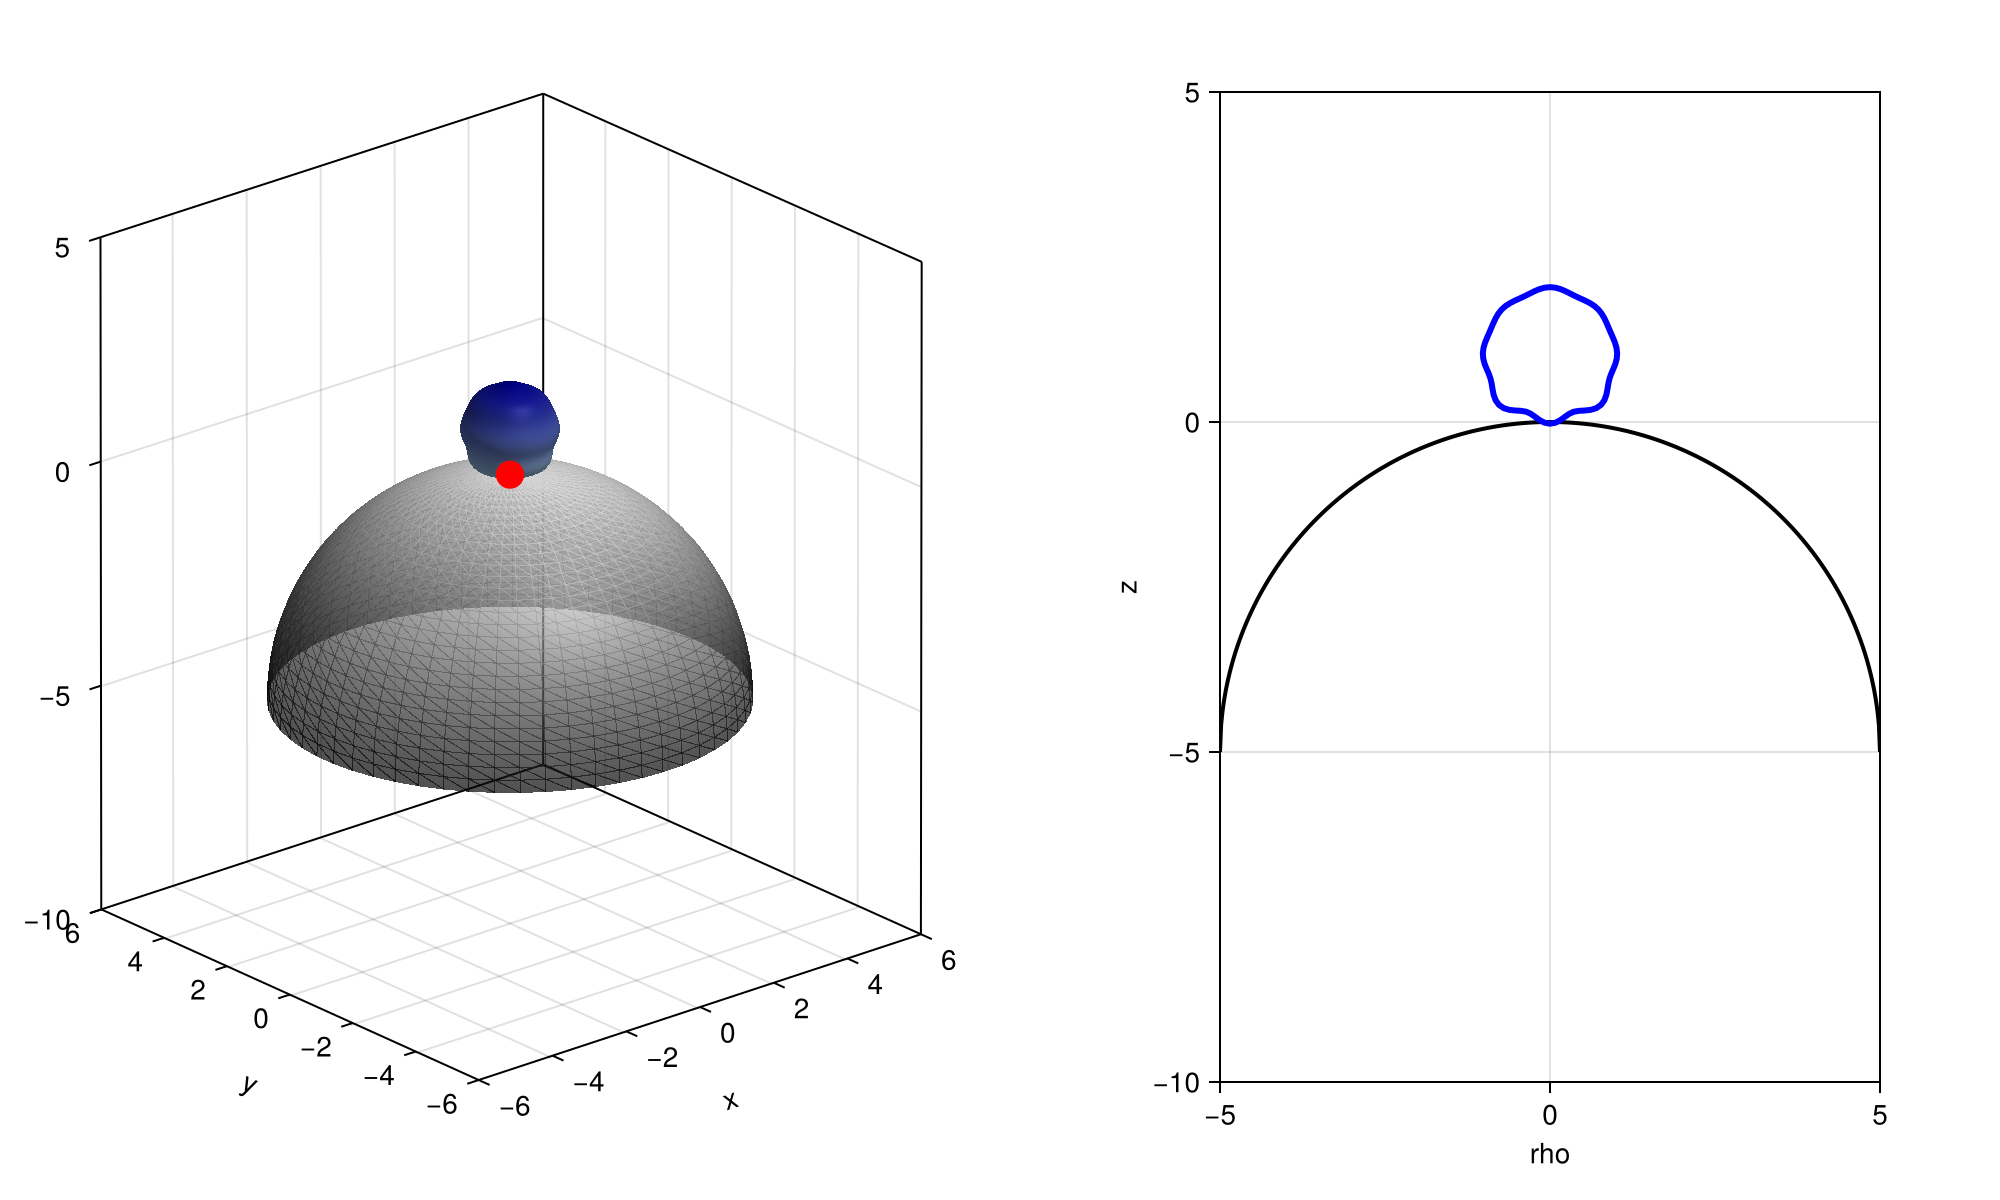

In [35]:

"""
Animate the 3D droplet and a 2D cross section through the symmetry plane.
"""
function drop_simulation_and_cross_section(all_amps_list, all_h_list, all_m_list, all_times_list, n_thetas_int; speeds=20, view_vertical=20, view_horizontal=50, 
    layers=60, r_min=1e-3,
    R0=1.0,
    eta_max=0.08,
    l_cut=8)

    """
    Function that animates the droplet's motion on a spherical substrate.
    """

    theta_max = π
    theta = range(0, theta_max, length=n_thetas_int)
    cos_theta = cos.(theta)
    sin_theta = sin.(theta)

    phi = range(0, 2π, length=layers)
    cos_phi = cos.(phi)
    sin_phi = sin.(phi)

    all_amps_arr = hcat(all_amps_list...)'
    M = size(all_amps_arr, 2)

    legvals = zeros(n_thetas_int, M)
    for l in 2:(M + 1)
        @inbounds for i in 1:n_thetas_int
            legvals[i, l - 1] = Legendre(cos_theta[i], l)
        end
    end

    l = collect(2:(M + 1))
    taper = exp.(-((l .- 2) ./ max(l_cut - 2, 1)).^4)
    taper[l .<= l_cut] .= 1.0

    fig = GLMakie.Figure(size=(1000, 600))
    ax3d = GLMakie.Axis3(fig[1, 1]; aspect=:data)
    ax2d = GLMakie.Axis(fig[1, 2]; xlabel="rho", ylabel="z", aspect=DataAspect())

    rxy = max(1.5, Ra + 1.0)
    z_center = -Ra / 2
    z_extent = max(Ra, R0) * 1.5

    limits!(ax3d, (-rxy, rxy), (-rxy, rxy), (z_center - z_extent, z_center + z_extent))

    cam3d!(ax3d.scene; elevation=view_vertical, azimuth=view_horizontal)
    draw_spherical_substrate!(ax3d, Ra, layers)

    # Dome cross-section (mirror for full view)
    rho_dome = range(0, Ra, length=300)
    z_dome = @. -Ra * (1 - sqrt(1 - (rho_dome / Ra)^2))
    rho_dome_full = vcat(-reverse(rho_dome), rho_dome)
    z_dome_full = vcat(reverse(z_dome), z_dome)
    GLMakie.lines!(ax2d, rho_dome_full, z_dome_full; color=:black, linewidth=2)

    x_layer = zeros(n_thetas_int, layers)
    y_layer = similar(x_layer)
    z_layer = similar(x_layer)

    radii = similar(theta)
    eta = zeros(n_thetas_int)

    # Droplet cross-section buffers (mirrored)
    rho_drop_full = zeros(2 * n_thetas_int)
    z_drop_full = zeros(2 * n_thetas_int)

    function compute_surface!(x, y, z, r, h)
        @inbounds for i in 1:n_thetas_int
            ri = r[i]
            rhoi = ri * sin_theta[i]
            zi = h + ri * cos_theta[i]
            for j in 1:layers
                x[i, j] = rhoi * cos_phi[j]
                y[i, j] = rhoi * sin_phi[j]
                z[i, j] = zi
            end
        end
    end

    radii .= R0
    h_eff = -R0 * cos(theta_max)
    compute_surface!(x_layer, y_layer, z_layer, radii, h_eff)

    surfaceplot = GLMakie.surface!(ax3d, x_layer, y_layer, z_layer, colormap=:blues)
    drop_section = GLMakie.lines!(ax2d, rho_drop_full, z_drop_full; color=:blue, linewidth=3)

    GLMakie.xlims!(ax2d, -max(Ra, 1.5R0), max(Ra, 1.5R0))
    GLMakie.ylims!(ax2d, z_center - z_extent, z_center + z_extent)

    contact = GLMakie.scatter!(ax3d, [0.0], [0.0], [0.0], color=:green, markersize=20)

    h_offset = all_h_list[1]

    frame_indices = 1:2:length(all_amps_list)
    p = Progress(length(frame_indices))

    GLMakie.record(fig, "droplet_with_cross_section.gif", frame_indices; framerate=speeds) do frame
        fill!(eta, 0.0)
        for col in 1:M
            eta .+= taper[col] * all_amps_arr[frame, col] .* view(legvals, :, col)
        end

        scale = maximum(abs.(eta)) > 0 ? min(1.0, eta_max / maximum(abs.(eta))) : 1.0
        radii .= R0 .* (1 .+ scale .* eta)
        radii .= max.(radii, r_min)

        h_dyn = h_eff + (all_h_list[frame] - h_offset) # dynamic height 

        gap_min = Inf
        for i in 1:n_thetas_int
            rhoi = radii[i] * sin_theta[i]
            if rhoi < Ra
                z_drop_i = h_dyn + radii[i] * cos_theta[i]
                z_dome_i = -Ra * (1 - sqrt(1 - (rhoi / Ra)^2))
                gap_min = min(gap_min, z_drop_i - z_dome_i)
            end
        end

        in_contact = gap_min ≤ 1e-3 * R0
        if in_contact && h_dyn < h_eff
            h_dyn = h_eff
        end

        compute_surface!(x_layer, y_layer, z_layer, radii, h_dyn)

        # Mirrored droplet cross-section: (-rho, z) and (+rho, z), so we can how both sides
        @inbounds for i in 1:n_thetas_int
            rho = radii[i] * sin_theta[i]
            z = h_dyn + radii[i] * cos_theta[i]

            rho_drop_full[i] = -rho
            z_drop_full[i] = z

            rho_drop_full[2 * n_thetas_int - i + 1] = rho
            z_drop_full[2 * n_thetas_int - i + 1] = z
        end

        surfaceplot[1] = x_layer
        surfaceplot[2] = y_layer
        surfaceplot[3] = z_layer
        drop_section[1] = rho_drop_full
        drop_section[2] = z_drop_full

        contact.color[] = in_contact ? :red : :green
        next!(p)
        surfaceplot, contact
    end

    finish!(p)
    return fig
end

drop_simulation_and_cross_section(all_amps_list, all_h_list, all_m_list, all_times_list, n_thetas; speeds=20)


## Pressure Animation 

In [36]:
# First, let's check the actual structure of all_press_list
println("Type of all_press_list: ", typeof(all_press_list))
println("Length of all_press_list: ", length(all_press_list))
if length(all_press_list) > 0
    println("Type of first element: ", typeof(all_press_list[1]))
    println("Length of first element: ", length(all_press_list[1]))
    if length(all_press_list[1]) > 0
        println("Type of first element of first element: ", typeof(all_press_list[1][1]))
    end
end

function pressure_simulation(all_press_list, all_times_list, n_thetas_int, speeds)
    legendre_roots, _ = gausslegendre(n_thetas_int)
    float_roots = vcat(reverse(legendre_roots), legendre_roots)

    # Check if we need to extract from nested structure or use directly
    if length(all_press_list) > 0 && isa(all_press_list[1], Vector) && length(all_press_list[1]) > 0 && isa(all_press_list[1][1], Vector)
        # Original nested structure
        all_press_arr = [all_press_list[i][j][1] for i in 1:length(all_press_list), j in 1:length(all_press_list[1])]
    else
        # Current simple structure - convert to array
        all_press_arr = hcat(all_press_list...)'
    end

    n_frames, n_thetas = size(all_press_arr)

    cos_angles = cos.(float_roots) # Pre calculate cosines of angles for efficiency
    pressures = zeros(length(float_roots))

    anim = @animate for n in 1:n_frames
        pressures .= 0.0  # Reset pressures

        @inbounds for i in 1:(n_thetas - 1) # Loop through each Legendre mode
            coeff = all_press_arr[n, i] # Coefficient for the current mode
            # Calculate the pressure contribution for each angle using Legendre polynomial
            # Reminder: Legendre evaluates the polynomial at cos_angles
            pressures .+= coeff .* Legendre.(cos_angles, i)
        end

        Plots.plot(float_roots, pressures; ylim=(-0.1,6), xlim=(-1,1), xlabel="X",
             ylabel="Y", title="Pressure Amplitude", legend=false)
    end every=1

    gif(anim, "pressure_simulation.gif", fps=max(speeds, 1))

    return "GIF saved as pressure_simulation.gif"
end


# Example Call
tend = 100
t = LinRange(0, tend, tend + 1)
pressure_simulation(all_press_list, t, n_thetas, 20)

Type of all_press_list: Vector{Vector{Float64}}
Length of all_press_list: 90
Type of first element: Vector{Float64}
Length of first element: 41
Type of first element of first element: Float64


[ Info: Saved animation to /Users/marina.levay/Documents/GitHub/drop_simulations/spherical_surface_simulations/pressure_simulation.gif


"GIF saved as pressure_simulation.gif"

## Coefficient of Restitution

In [37]:
"""
Calculates and prints the Coefficient of Restitution.

Inputs/ Uses:
all_h_list (list): List of heights.
all_v_list (list): List of velocities.
all_m_list (list): List of contact points.
all_times_list (list): List of all time steps.

Outputs:
Prints the coefficient of restitution and the contact time.
"""

result = coefficient_of_restitution(all_h_list, all_v_list, all_m_list, all_times_list)

if result !== nothing
    coeff, t_contact = result
    println("Coefficient of Restitution: $coeff")
    println("Contact Time: $t_contact")
else
    println("Droplet did not rebound (or contact condition for restitution not met).")
end

Droplet did not rebound (or contact condition for restitution not met).


# Simulation Diagnosis

To verify for Infs and NaN values (which may indicate numerical issues)

In [38]:
"""
Scan simulation outputs for NaN/Inf values and structural mismatches.
"""
function diagnose_simulation_data(all_amps_list, all_h_list, all_m_list)
    issues = false

    n = length(all_h_list)
    if length(all_amps_list) != n || length(all_m_list) != n
        println("Length mismatch: amps=$(length(all_amps_list)) h=$(n) m=$(length(all_m_list))")
        issues = true
    end

    if any(!isfinite, all_h_list)
        idx = findall(x -> !isfinite(x), all_h_list)
        println("Non-finite values in all_h_list at indices: ", idx)
        issues = true
    end

    if any(!isfinite, all_m_list)
        idx = findall(x -> !isfinite(x), all_m_list)
        println("Non-finite values in all_m_list at indices: ", idx)
        issues = true
    end

    bad_amp_indices = Int[]
    for (i, amps) in enumerate(all_amps_list)
        if any(!isfinite, amps)
            push!(bad_amp_indices, i)
        end
    end
    if !isempty(bad_amp_indices)
        println("Non-finite values in all_amps_list entries at indices: ", bad_amp_indices)
        issues = true
    end

    if !isempty(all_amps_list)
        lens = map(length, all_amps_list)
        if !all(l -> l == first(lens), lens)
            println("Amplitude vector length varies across time steps. Unique lengths: ", unique(lens))
            issues = true
        end
    end

    if !issues
        println("No NaN/Inf values found; data arrays appear consistent.")
    end
    return nothing
end


diagnose_simulation_data

### Diagnostics

Run the diagnostic helper after the simulation and before visualization if you suspect numerical issues.
It checks for NaN/Inf values and mismatched lengths in the main time-series arrays.


In [39]:
## Run Diagnostic Checks

# Execute diagnostic function to identify the source of numerical issues
println("Running diagnostic checks on simulation data...\n")

diagnose_simulation_data(all_amps_list, all_h_list, all_m_list)

println("\nHow to interpret results:")
println("- If NaN/Inf values found: there's a problem in the Newton Solver")
println("- If no NaN/Inf values: there's a problem in the visualization method")

Running diagnostic checks on simulation data...

No NaN/Inf values found; data arrays appear consistent.

How to interpret results:
- If NaN/Inf values found: there's a problem in the Newton Solver
- If no NaN/Inf values: there's a problem in the visualization method
